# CUTS-Plus Lightning 示例

本 Notebook 演示如何使用当前仓库的 Lightning 化实现来训练 CUTS-Plus，并导出与可视化最终因果图 `Graph.npy`。


In [1]:
# 环境与路径设置
import os, sys, time
import torch

# 可选：Tensor Cores 上更快的 float32 matmul
if torch.cuda.is_available():
    try:
        torch.set_float32_matmul_precision('medium')
    except Exception:
        pass

# 将项目根目录加入 sys.path（假设本 notebook 位于项目根目录）
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")


PROJECT_ROOT = /home/acme/yhy/STCausalPatch
CUDA available: True


In [2]:
# 导入依赖
from datetime import datetime
from omegaconf import OmegaConf
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

# 项目内模块
from dataset.lorenz_datamodule import Lorenz96DataModule
from lightning_module import CUTSPlusLightning
from utils.misc import reproduc



In [3]:
# 加载配置与初始化 Logger/DataModule
config_path = "configs/lorenz_example.yaml"
opt = OmegaConf.load(config_path)

# 复现性
reproduc(**opt.reproduc)

# 任务名与日志
timestamp = datetime.now().strftime("_%Y%m%d_%H%M%S")
opt.task_name = (opt.task_name or "lorenz_cuts") + "_nb" + timestamp
log_dir = os.path.join(opt.dir_name, opt.task_name)
print(f"Logs will be saved to: {log_dir}")

# Logger（Lightning）
logger = TensorBoardLogger(save_dir=opt.dir_name, name=opt.task_name, default_hp_metric=False)

# DataModule
print("Setting up datamodule...")
datamodule = Lorenz96DataModule(
    data_config=opt.data,
    train_config=opt.sota.cuts_plus,
    reproduc_config=opt.reproduc,
)
datamodule.setup('fit')



Logs will be saved to: outputs/lorenz_cuts_nb_20251103_152044
Setting up datamodule...
Data shape: (1000, 128)
Resolved 'n_nodes: auto' to 128
Initial observable data ratio: 0.7004


In [4]:
# 初始化 LightningModule 与 Trainer，并开始训练
model = CUTSPlusLightning(
    train_config=opt.sota.cuts_plus,
    reproduc_config=opt.reproduc,
)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
trainer = pl.Trainer(
    max_epochs=opt.sota.cuts_plus.total_epoch,
    logger=logger,
    accelerator=accelerator,
    devices=1,
    log_every_n_steps=10,
    check_val_every_n_epoch=opt.sota.cuts_plus.show_graph_every,
    enable_checkpointing=False,
    deterministic=opt.reproduc.deterministic,
)

trainer.fit(model, datamodule=datamodule)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name      | Type          | Params | Mode 
----------------------------------------------------
0 | model     | CUTS_Plus_Net | 31.4 K | train
1 | pred_loss | MSELoss       | 0      | train
----------------------------------------------------
31.4 K    Trainable params
0         Non-trainable params
31.4 K    Total params
0.125     Total estimated model params size (MB)
157       Modules in train mode
0         Modules in eval mode


Data shape: (1000, 128)
Initial observable data ratio: 0.7004


/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 10:   0%|          | 0/8 [00:00<?, ?it/s, v_num=0, train/pred_loss_step=0.764, train/graph_sparsity_loss_step=0.620, train/pred_loss_epoch=0.766, train/graph_sparsity_loss_epoch=0.620]       

/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


...

Epoch 40:   0%|          | 0/8 [00:00<?, ?it/s, v_num=0, train/pred_loss_step=0.621, train/graph_sparsity_loss_step=0.596, train/pred_loss_epoch=0.597, train/graph_sparsity_loss_epoch=0.596, metrics/auc=0.998]        Epoch 40: Initialized/Updated graph optimizer. n_groups=128, graph_lr=2.78e-04


/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorc

Epoch 63: 100%|██████████| 8/8 [00:00<00:00, 15.36it/s, v_num=0, train/pred_loss_step=0.574, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.578, train/graph_sparsity_loss_epoch=0.591, metrics/auc=0.999]Warning: Failed to log time series plot. log_time_series() missing 2 required positional arguments: 'log' and 'log_step'


`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63: 100%|██████████| 8/8 [00:01<00:00,  4.16it/s, v_num=0, train/pred_loss_step=0.574, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.578, train/graph_sparsity_loss_epoch=0.591, metrics/auc=0.999]
Saved final causal graph to outputs/lorenz_cuts_nb_20251103_152044/version_0/Graph_final.npy


Reading Graph_final.npy from: outputs/lorenz_cuts_nb_20251103_152044/version_0/Graph_final.npy
Graph shape: (128, 128)


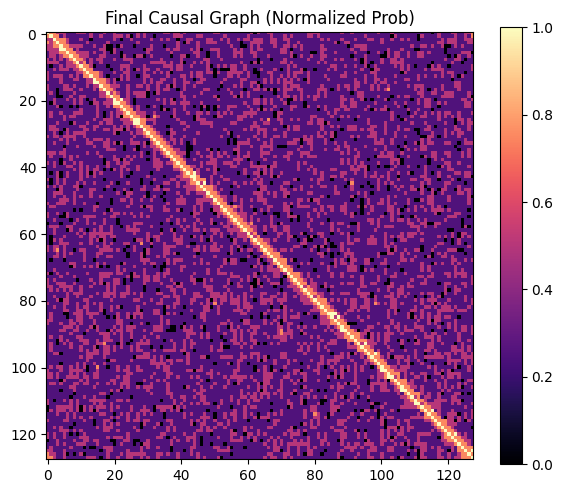

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 确定日志目录 ---
# 假设 'logger' 变量 (例如 tb_logger) 存在于当前作用域
# (即你定义 trainer 时传入的那个 logger 对象)

log_dir_guess = None

# 检查 'logger' 变量是否存在
if 'logger' in locals() or 'logger' in globals():
    if hasattr(logger, 'log_dir') and logger.log_dir is not None:
        # 这是最可靠的属性 (Pytorch Lightning 1.5+ 常用)
        log_dir_guess = logger.log_dir
    elif hasattr(logger, "save_dir") and hasattr(logger, "name") and hasattr(logger, "version"):
        # 这是备用方案，用于 Pytorch Lightning 的默认 logger 结构
        log_dir_guess = os.path.join(logger.save_dir, logger.name, f"version_{logger.version}")
    else:
        print("找到了 'logger' 对象, 但无法确定 'log_dir' 或 'save_dir' 属性。")
else:
    print("未在当前作用域中找到 'logger' 变量。")
    print("请手动设置 'log_dir_guess' 的路径, 例如: 'lightning_logs/version_0'")
    # 示例: log_dir_guess = "lightning_logs/version_0"

if log_dir_guess:
    # --- 2. 修正文件名 ---
    # 在重构后的 on_fit_end 中，文件名被保存为 'Graph_final.npy'
    graph_path = os.path.join(log_dir_guess, 'Graph_final.npy')
    print(f"Reading Graph_final.npy from: {graph_path}")

    # --- 3. 加载和绘图 (逻辑不变) ---
    if os.path.exists(graph_path):
        Graph = np.load(graph_path)
        print("Graph shape:", Graph.shape)

        # 归一化 (避免除以零)
        min_val, max_val = np.min(Graph), np.max(Graph)
        if max_val - min_val > 1e-6:
            graph_normalized = (Graph - min_val) / (max_val - min_val)
        else:
            graph_normalized = Graph # 已经是平面

        plt.figure(figsize=(6, 5))
        # 使用归一化后的图进行可视化
        plt.imshow(graph_normalized, cmap='magma', vmin=0, vmax=1)
        plt.title('Final Causal Graph (Normalized Prob)')
        plt.colorbar()
        plt.tight_layout()
        plt.show()
    else:
        print(f"File not found: {graph_path}")
        print("请检查训练是否已完成，以及 logger 路径是否正确。")
else:
    print("无法确定日志目录, 脚本终止。")

## 运行 Lorenz patches 版本实验

下面的单元将使用 `configs/lorenz_patches_example.yaml`，训练并可视化结果，同时展示 ground truth（true_cm）。


In [6]:
# 载入 patches 配置并训练
opt2 = OmegaConf.load("configs/lorenz_patches_example.yaml")

# 复现性
reproduc(**opt2.reproduc)

# Logger / DataModule / Model / Trainer
logger2 = TensorBoardLogger(save_dir=opt2.dir_name, name=opt2.task_name + "_nb", default_hp_metric=False)

datamodule2 = Lorenz96DataModule(
    data_config=opt2.data,
    train_config=opt2.sota.cuts_plus,
    reproduc_config=opt2.reproduc,
)
datamodule2.setup('fit')

model2 = CUTSPlusLightning(
    train_config=opt2.sota.cuts_plus,
    reproduc_config=opt2.reproduc,
)

accelerator2 = 'gpu' if torch.cuda.is_available() else 'cpu'
trainer2 = pl.Trainer(
    max_epochs=opt2.sota.cuts_plus.total_epoch,
    logger=logger2,
    accelerator=accelerator2,
    devices=1,
    log_every_n_steps=10,
    check_val_every_n_epoch=opt2.sota.cuts_plus.show_graph_every,
    enable_checkpointing=False,
    deterministic=opt2.reproduc.deterministic,
)

trainer2.fit(model2, datamodule=datamodule2)



/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data shape: (1000, 128)
Resolved 'n_nodes: auto' to 128
Initial observable data ratio: 0.7004


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name      | Type                      | Params | Mode 
----------------------------------------------------------------
0 | model     | CUTS_Plus_Transformer_Net | 49.5 K | train
1 | pred_loss | MSELoss                   | 0      | train
----------------------------------------------------------------
49.5 K    Trainable params
0         Non-trainable params
49.5 K    Total params
0.198     Total estimated model params size (MB)
180       Modules in train mode
0         Modules in eval mode


Data shape: (1000, 128)
Initial observable data ratio: 0.7004


/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 63: 100%|██████████| 8/8 [00:00<00:00, 13.26it/s, v_num=5, train/pred_loss_step=0.0286, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.0277, train/graph_sparsity_loss_epoch=0.591, metrics/auc=0.866]

`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63: 100%|██████████| 8/8 [00:02<00:00,  3.80it/s, v_num=5, train/pred_loss_step=0.0286, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.0277, train/graph_sparsity_loss_epoch=0.591, metrics/auc=0.866]


Reading Graph.npy from: outputs/lorenz_patches_cuts_nb/version_5
Graph shape: (128, 128)


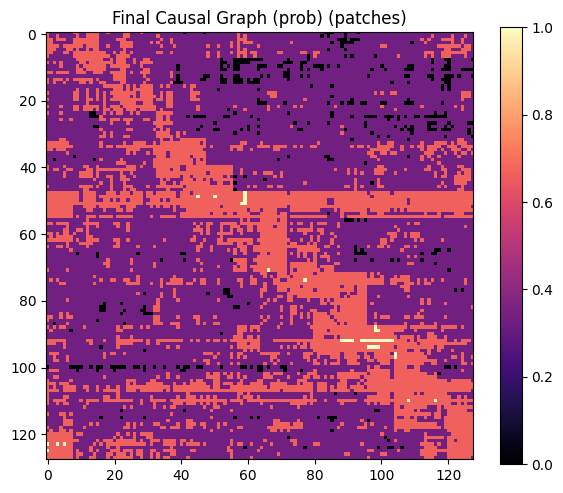

In [7]:
# 读取导出的 Graph.npy 并做简单可视化
import numpy as np
import matplotlib.pyplot as plt

# lightning_module.on_fit_end 会将 Graph.npy 保存到 logger 目录
log_dir2 = None
if hasattr(logger2, 'log_dir') and logger2.log_dir is not None:
    log_dir2 = logger2.log_dir
else:
    log_dir2 = os.path.join(logger2.save_dir, logger2.name, f"version_{logger2.version}")

print(f"Reading Graph.npy from: {log_dir2}")
graph_path2 = os.path.join(log_dir2, 'Graph.npy')

if os.path.exists(graph_path2):
    Graph2 = np.load(graph_path2)
    print("Graph shape:", Graph2.shape)
    graph2 = (Graph2 - np.min(Graph2)) / (np.max(Graph2) - np.min(Graph2))

    plt.figure(figsize=(6, 5))
    plt.imshow(graph2, cmap='magma', vmin=0, vmax=1)
    plt.title('Final Causal Graph (prob) (patches)')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Graph.npy not found for patches experiment. Check that training finished and saving succeeded.")

